In [15]:
import os
import glob
import numpy as np
import dill
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from copy import deepcopy
import scipy

In [16]:
# Paths
path_figs   = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"

In [17]:
# General info of the cases
min_t_all_cases = {"CASE1": 420,
                  "CASE2_new": 270,
                  "CASE3_new": 450}

label_cases    = {"CASE1": "a)",
                 "CASE2_new": "b)", 
                 "CASE3_new": "c)" }

name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}

sub_case = {"CASE1": "a) Moree Aero", 
           "CASE2_new": "b) Wagga Wagga",
           "CASE3_new": "c) Tamworth Airport"}

In [19]:
def load_tracking_paths(case, dom, downdrafts=True):
    """
    Returns paths and file lists for thermal tracking cases.

    Parameters:
        case (str): Case name, e.g., "CASE1" or "CASE2_new"
        downdrafts (bool): True for descending thermals, False for ascending thermals

    Returns:
        path_track (str): Base folder of tracking data
        path_grid (str): Folder where grids are saved
        dd_all (list): Sorted list of npy files for each thermal
        index_all (list): Index list corresponding to dd_all
        dd_all_entr (list): Sorted list of net entrainment files
    """

   # Determine folder prefix
    prefix = "thermal_tracking" if downdrafts else "uw_thermal_tracking"

    # Handle CASE1 vs others
    base_case = case.lower() if case == "CASE1" else case.split("_new")[0].lower()

    # Paths
    path_track = f"/g/data/up6/ai2733/Gusts_downdrafts/thermal_tracking_code/{prefix}_{base_case}_cropped/thermals_all/"

    if downdrafts: subdir = "" if dom == "d03" else "Alld02_new/"
    else: subdir = "" if dom == "d03" else "Alld02/"

    if dom == "d03": path_save = f"/g/data/w28/ai2733/outputs_{case}_budgets/grid_tracking_cropped_new/{subdir}"
    else: path_save  = f"/g/data/w28/ai2733/outputs_{case}_budgets/grid_tracking_cropped_new_d02/{subdir}"

    # File patterns
    file_type = "downdraft_*" if downdrafts else "thermal_*"
    dd_all      = sorted(glob.glob(f"{path_track}/{file_type}/{file_type}_data.npy"))

    index_all = list(range(len(dd_all)))

    print(case, dom)
    print(f"Found {len(dd_all)} files")

    return path_track, path_save, subdir, dd_all, index_all

In [4]:
def plot_density_axis(ax, *series, labels, bins = [], ylabel = False, legend = False, nbins=15, title="", x_label="X Axis", density=False, prec = 2, colors = ["blue", "orange", "green"], units = []):
    """
    Function to plot the density (relative frequency) for multiple time series.

    Parameters:
        *series: multiple time series (arrays) to plot
        labels: list of labels for each time series
        nbins: number of bins for the histograms (default is 15)
        title: title of the plot (default is "")
        x_label: label for the x-axis (default is "X Axis")
    """

    if len(bins) == 0:
        # Determine the min and max values across all time series
        min_val = np.min([np.min(s) for s in series])
        max_val = np.max([np.max(s) for s in series])
    
        # Set the bin edges for the histograms
        bins = np.linspace(min_val, max_val, nbins)

    # Loop through each series and plot its density
    for i, s in enumerate(series):
        # Calculate the histogram and relative frequency
        h, b = np.histogram(s, bins=bins)
        if density:
            h_rel = 100 * h / float(np.sum(h))
        else:
            h_rel = h

        # Calculate the bin centers for plotting
        xbins = b[:-1] + (b[1:] - b[:-1]) / 2.

        # Plot the density for the current series on the specified axis
        mean = np.round(float(np.round(np.mean(s),2)),2)
        a = ax.plot(xbins, h_rel, label=f"{labels[i]}: {mean} {units[i]}", lw=3., alpha=0.7, c = colors[i])

        ax.axvline(x = np.mean(s), ls = "--", c = a[0].get_color())

            
    # Set plot titles and labels
    ax.set_title(title)
    ax.set_xlabel(x_label)
    if ylabel:
        if density: 
            ax.set_ylabel(u"Frequency [%]")
        else: 
            ax.set_ylabel(u"Count")

    if legend:
        ax.legend(loc="upper right", frameon=False)#, bbox_to_anchor= [1,1])

    else:
        ax.text(
            0.98, 0.98, f"Mean: {mean} {units[i]}",  # position (x, y) in axis fraction
            transform=ax.transAxes,          # coordinate system of the axes
            ha="right", va="top",            # align text anchor
            fontsize=14)
    ax.grid(axis="y", ls="--")


In [5]:
def get_all_data(case):

    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    # Function to read the tracked data, the WRF grid, and get all data needed to run the plots
    Parameters: case
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    
    ##################################
    # Read tracked downdrafts
    ##################################
    
    path_case, path_case1, path_save, subdir, dd_all, index_all = load_tracking_paths(case, dom = "d03", downdrafts = True)
    
    # Save variables of interest
    data_filt = {}
    time_all = []
    x_max_all = []
    y_max_all = []
    z_max_all = []
    x_centre_all = []
    y_centre_all = []
    z_centre_all = []
    w_centre_all = []
    r_all = []
    w_mean_all = []
    w_mean_mean = []
    w_final = []
    
    for idx, i in enumerate(dd_all):
        # All variables contained in the data!--From _write_data_to_file in WRD_3Dthermal
        dd_data = np.load(i)
        time, w_centre,R_thermal,mass, xmax, ymax, hmax, x_centre, y_centre,z_centre, u_mean, v_mean, w_mean,PnzdS, zmomflux,buoy,buoy_m, acc,PnxdS,xmomflux,PnxdSplusXmomflux,PnydS, ymomflux,PnydSplusYmomflux, entr_dist,entr_rate,pos_exp, detr_dist, mse_thermal,mse_env,latheat_thermal,maxlatheat_thermal, qnice_thermal,qncloud_thermal,qnrain_thermal, cldnuc_thermal, rh_thermal, qcloud_thermal, qrain_thermal, qice_thermal, qvapor_thermal, sctot_thermal,maxsctot_thermal, noninduc_thermal, epotential_thermal,maxepotential_thermal,qngraupel_thermal, qicesnow_thermal, qghail_thermal,date = dd_data        
        
        xmax = xmax*1e3, 
        ymax = ymax*1e3, 
        hmax = hmax*1e3, 
        x_centre = x_centre*1e3, 
        y_centre = y_centre*1e3, 
        z_centre = z_centre*1e3,  
        
        time_all.append(time)
        x_max_all.append(xmax)
        y_max_all.append(ymax)
        z_max_all.append(hmax)
        
        x_centre_all.append(x_centre)
        y_centre_all.append(y_centre)
        z_centre_all.append(z_centre)
        w_centre_all.append(w_centre)
        
        r_all.append(R_thermal)
        w_mean_mean.append(w_mean.mean())
        w_mean_all.append(w_mean)
        w_final.append(w_mean[-1])
        
    # Some arrays that I am interested in 
    w_final         = np.array(w_final)
    z_final         = np.array([i[0][-1] for i in z_max_all])
    z_init          = np.array([i[0][0] for i in z_max_all])
    w_mean_mean     = np.array(w_mean_mean)
    r_mean          = np.array([np.mean(r) for r in r_all])
    min_t_all       = min_t_all_cases[case]
    
    ##################################
    # Read WRF grid
    ##################################
    
    with open(f'{path_save}/data_grid.pkl', 'rb') as f: data_grid = dill.load(f)
    
    x_grid = data_grid["x_grid"]
    y_grid = data_grid["y_grid"]
    hgt_c  = data_grid["hgt_c"]
    nx = data_grid["nx"]
    ny = data_grid["ny"]
    nz = data_grid["nz"]
    i0, i1 = data_grid["i0"], data_grid["i1"]
    j0, j1 = data_grid["j0"], data_grid["j1"]
    
    # Open xarrays just the variables I need
    with open(f'{path_save}/gust_all.pkl', 'rb')        as f: gust_all = dill.load(f)
    with open(f'{path_save}/height_all.pkl', 'rb')      as f: height_all = dill.load(f)
    with open(f'{path_save}/wa_all.pkl', 'rb')          as f: wa_all = dill.load(f)
    
    wrf_all = {"WSMAX":gust_all,
        "height":height_all, 
        "wa":wa_all}
    
    ##################################
    ### POSITIONS OF DD: CENTRE
    ##################################
    
    ix_centr_all = []
    iy_centr_all = []
    iz_centr_all = []
    iz_centr_all2 = []
    
    t_max_all = []
    for thermal_idx in index_all:
        # Positions of w centre
        ix_centr = np.interp(x_centre_all[thermal_idx], x_grid, np.arange(nx)).round()[0].astype(int) # indices (as floats) of centre positions
        iy_centr = np.interp(y_centre_all[thermal_idx], y_grid, np.arange(ny)).round()[0].astype(int)
        
        ix_centr_all.append(ix_centr)
        iy_centr_all.append(iy_centr)
        
        time_max = (time_all[thermal_idx] - min_t_all).astype(int)
    
        # I know the "height" of the dd (in interpolated grid), I interpolate again to get position in the original grid
        iz_max = []
        for idx_t, t in enumerate(time_max):
            hgt_t =   np.array(wrf_all["height"].sel(west_east = ix_centr[idx_t], south_north = iy_centr[idx_t], Time = t))
            iz_max.append(np.interp([z_centre_all[thermal_idx][0][idx_t]], hgt_t, np.arange(nz)).round()[0].astype(int))
        
        iz_centr_all.append(iz_max)
        

    ##################################
    ### POSITIONS OF DD: wmin
    ##################################
    
    ix_max_all = []
    iy_max_all = []
    iz_max_all = []
    w_min_all   = []
    
    t_max_all = []
    for thermal_idx in index_all:
        # Positions of wmax
        ix_max = np.interp(x_max_all[thermal_idx], x_grid, np.arange(nx)).round()[0].astype(int) # indices (as floats) of centre positions
        iy_max = np.interp(y_max_all[thermal_idx], y_grid, np.arange(ny)).round()[0].astype(int)
        
        time_max = (time_all[thermal_idx] - min_t_all).astype(int)
        t_max_all.append(time_max)
    
        ix_max_all.append(ix_max)
        iy_max_all.append(iy_max)
        
        # I know the "height" of the dd (in interpolated grid), I interpolate again to get position in the original grid
        iz_max = []
        for idx_t, t in enumerate(time_max):
            hgt_t =   np.array(wrf_all["height"].isel(west_east = ix_max[idx_t], south_north = iy_max[idx_t], Time = t))
            iz_max.append(np.interp([z_max_all[thermal_idx][0][idx_t]], hgt_t, np.arange(nz)).round()[0].astype(int))
        
        iz_max_all.append(iz_max)
        
        # Get W
        w_min  = []
        for idx_t, t in enumerate(time_max):
            w_min.append(wrf_all["wa"].isel(west_east = ix_max[idx_t], south_north = iy_max[idx_t], z = iz_max[idx_t], Time = t).item())
        
        w_min_all.append(w_min)        
        
    
    # Get all indices contained in each dd: according to centre and Radius
    indx_all = []
    indy_all = []
    indz_all = []
    
    for idx_thermal in range(len(r_all)):
        indx_dd = []
        indy_dd = []
        indz_dd = []
    
        # Get all cells contained in dd 
        R_thermal = r_all[idx_thermal]
        x_centre =  x_centre_all[idx_thermal][0]
        y_centre =  y_centre_all[idx_thermal][0]
        z_centre =  z_centre_all[idx_thermal][0]
        
        ix_max    = ix_centr_all[idx_thermal]
        iy_max    = iy_centr_all[idx_thermal]
        it_max    = t_max_all[idx_thermal]
        
        R_range = 0.0 # If I want to expand the CV in certain percentage of R
    
        for it in range(len(R_thermal)):
            indx1    = np.where((x_grid>=x_centre[it]-(1+R_range)*R_thermal[it])*(x_grid<=x_centre[it]+(1+R_range)*R_thermal[it]))[0]
            indy1    = np.where((y_grid>=y_centre[it]-(1+R_range)*R_thermal[it])*(y_grid<=y_centre[it]+(1+R_range)*R_thermal[it]))[0]
            
            hgt_t    = np.array(wrf_all["height"].isel(west_east = indx1, south_north = indy1, Time = it_max[it]))
            indz1    = np.where((hgt_t>=z_centre[it]-(1+R_range)*R_thermal[it])*(hgt_t<=z_centre[it]+(1+R_range)*R_thermal[it]))[0]
    
            indx_dd.append(indx1) ####### To look in bigger grid!+i0
            indy_dd.append(indy1) ####### To look in bigger grid!+j0
            indz_dd.append(indz1)
    
        indx_all.append(indx_dd)
        indy_all.append(indy_dd)
        indz_all.append(indz_dd)


    ##################################
    ### Get max gust around each thermal
    ##################################

    # After plotting this for all cases/domains, I decide which is the final buffer
    buffer_fin_case = {'CASE1': [4,4], # grid, time
                       'CASE2_new': [4,4],
                       'CASE3_new': [4,4]}
    
    def expand_array(arr, N):
        # Expand the array by N-1 numbers before the first element and after the last element
        if (arr[0] - N) >= 0:
            lim_ = arr[0] - N
        else:
            lim_ = 0
        return np.arange(lim_, arr[-1] + N + 1)
    
    def plot_scatter_Wgust():
        p1_fin, p2_fin = buffer_fin_case[f"{case}"]
    
        ws_max       = wrf_all["WSMAX"]
        wspd10max_neigh = []
        for thermal_idx in index_all:
            # Positions of wmax
            ix_max = ix_max_all[thermal_idx]
            iy_max = iy_max_all[thermal_idx]
    
            # I am just looking at the end of each dd lifetime
            times_thermal = t_max_all[thermal_idx]
            idx_t         = len(times_thermal)-1 
    
            # Ws10max in the neighborhood of the dd
            idx_all_dd = expand_array(indx_all[thermal_idx][idx_t], p1_fin)
            idy_all_dd = expand_array(indy_all[thermal_idx][idx_t], p1_fin)
            idz_all_dd = expand_array(indz_all[thermal_idx][idx_t], p1_fin)
            idt_all_dd = slice(times_thermal[idx_t],times_thermal[idx_t]+p2_fin+1)
            
            assert (idx_all_dd>=0).all()
            assert (idy_all_dd>=0).all()
            assert (idz_all_dd>=0).all()
            
            test_neigh = ws_max.isel(Time = idt_all_dd, 
                      south_north = idy_all_dd,
                      west_east   = idx_all_dd)
    
            wspd10max_neigh.append(np.array(test_neigh.max()))
            
        wspd10max_neigh = np.array(wspd10max_neigh)
        
        return wspd10max_neigh
    
    wspd10max_neigh = plot_scatter_Wgust()

    ####################################################
    ### Filter thermals 
    ####################################################
    
    # According to final height
    threshold_h = 2000 # meters
    index_H2000 = []
    for idx_thermal in index_all:
        idx_time2 = -1
        if z_max_all[idx_thermal][0][idx_time2]<=threshold_h: index_H2000.append(idx_thermal)

    # According to size
    thres_s = 1000. # meters
    r_mean = np.array([np.mean(r) for r in r_all])
    index_big = np.where(np.array(r_mean)>=thres_s)[0]
    index_small = np.array([i for i in index_all if i not in index_big])

    return index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all


## Figure 13: Histograms

In [6]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]

In [7]:
##########################################
# Get absolute min and max among every case
##########################################
min_r, max_r, min_w, max_w, min_lt, max_lt, min_zinit, max_zinit = [], [], [], [], [], [], [], []
for case in cases:
    # Get data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)
    len_dd = np.array([len(i) for i in time_all])
    min_r.append(r_mean.min())
    max_r.append(r_mean.max())
    min_w.append(w_mean_mean.min())
    max_w.append(w_mean_mean.max())
    min_lt.append(len_dd.min())
    max_lt.append(len_dd.max())
    min_zinit.append(z_init.min())
    max_zinit.append(z_init.max())
    
min_all_lifetime = np.min(min_lt)
max_all_lifetime = np.max(max_lt)

min_all_r = np.min(min_r)
max_all_r = np.max(max_r)

min_all_wmean = np.min(min_w)
max_all_wmean = np.max(max_w)

min_all_z = np.min(min_zinit)
max_all_z = np.max(max_zinit)

CASE1 d03
Found 1135 files
CASE2_new d03
Found 285 files
CASE3_new d03
Found 469 files


CASE1 d03
Found 1135 files


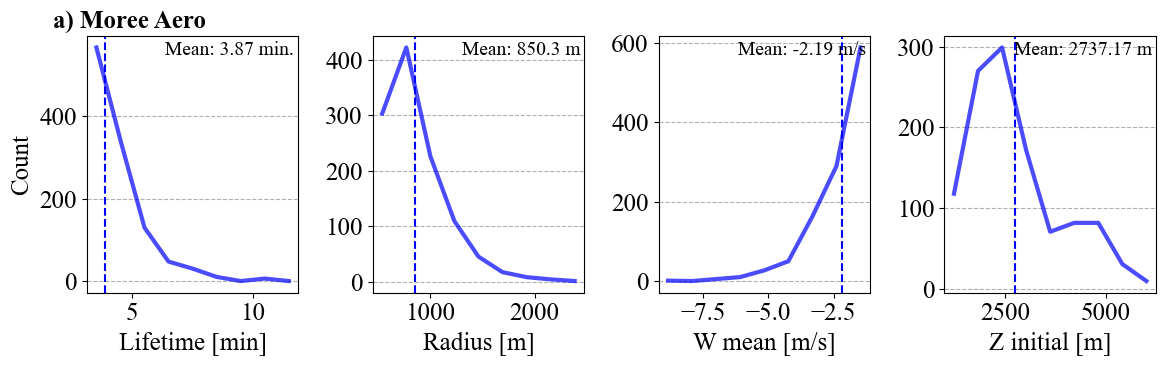

CASE2_new d03
Found 285 files


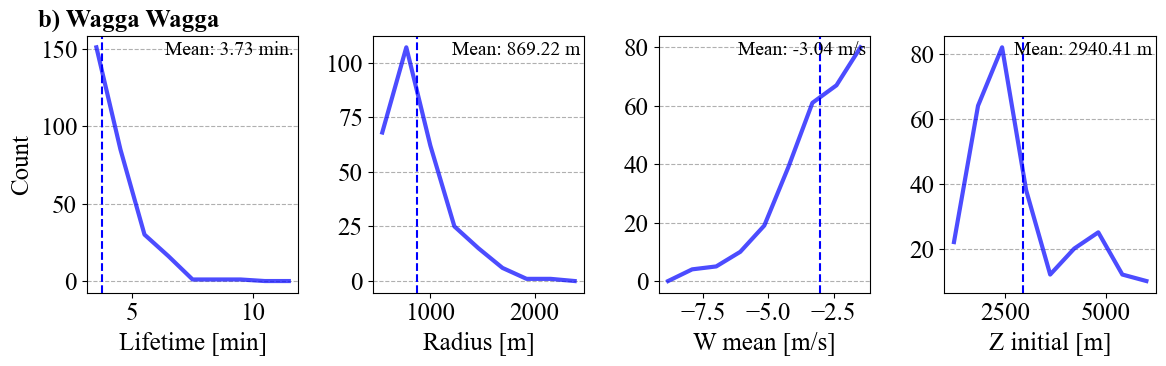

CASE3_new d03
Found 469 files


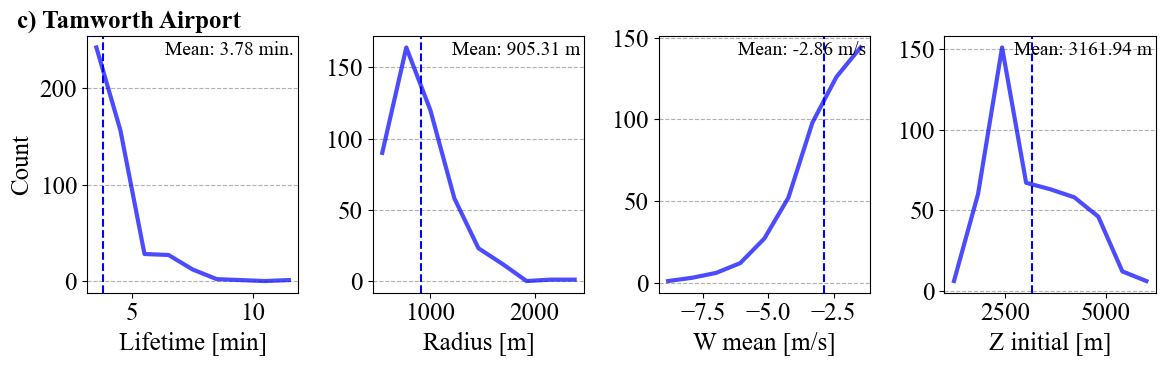

In [9]:
for case in cases:
    # Read data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)

    # Plot histograms
    fs = 18
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs,      # X tick label size
        "ytick.labelsize": fs,      # Y tick label size
        "legend.fontsize": fs-2,      # Legend font size
        "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })
    
    plt.figure(figsize=(12,4))
    
    density_ = False
    nbins_ = 10
    labels_1 = ["Mean"]
    
    # Fixed bins
    bins_lt = np.linspace(min_all_lifetime, max_all_lifetime, nbins_)
    bins_r = np.linspace(min_all_r, max_all_r, nbins_)
    bins_wmean = np.linspace(min_all_wmean, max_all_wmean, nbins_)
    bins_z = np.linspace(min_all_z, max_all_z, nbins_)
    
    #------------------------
    # Histograms of lifetime (min)
    #------------------------
    l1 = np.array([len(i) for i in time_all])
    plt.subplot(1, 4, 1)
    plot_density_axis(plt.gca(), l1, bins = bins_lt, labels=labels_1, ylabel = True, x_label="Lifetime [min]", density=density_, nbins=nbins_, units = ["min."])
    
    plt.title(f"{label_cases[case]} {name_cases[case]}", fontweight = "bold", x=0.2)
    
    #------------------------
    # Histograms of Radius: MEAN
    #------------------------
    r1 = r_mean
    plt.subplot(1, 4, 2)
    plot_density_axis(plt.gca(), r1, bins = bins_r, labels=labels_1, x_label="Radius [m]", density=density_, nbins=nbins_, units = ["m"])
    
    #------------------------------
    # Histograms of W: Mean from tracking code
    #------------------------------
    
    w1 = w_mean_mean
    plt.subplot(1, 4, 3)
    plot_density_axis(plt.gca(), w1, bins= bins_wmean, labels=labels_1, x_label="W mean [m/s]", density=density_, nbins=nbins_, units = ["m/s"])
    
    #------------------------
    # Histograms of Initial Z
    #------------------------
    z1 = z_init
    plt.subplot(1, 4, 4)
    plot_density_axis(plt.gca(), z1,  bins = bins_z, labels=labels_1, x_label="Z initial [m]", density=density_, nbins=nbins_, units = ["m"])
    
    plt.tight_layout()
    plt.savefig(f"{path_figs}/Figure13_{case}.png", dpi = 300, bbox_inches = "tight")
    plt.show()


## Figure 14: Scatter plots

CASE1 d03
Found 1135 files


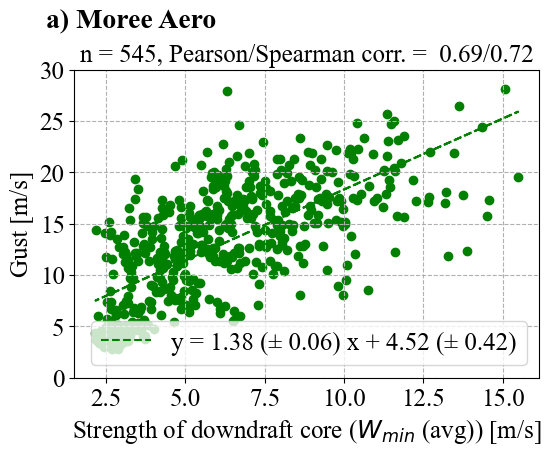

CASE2_new d03
Found 285 files


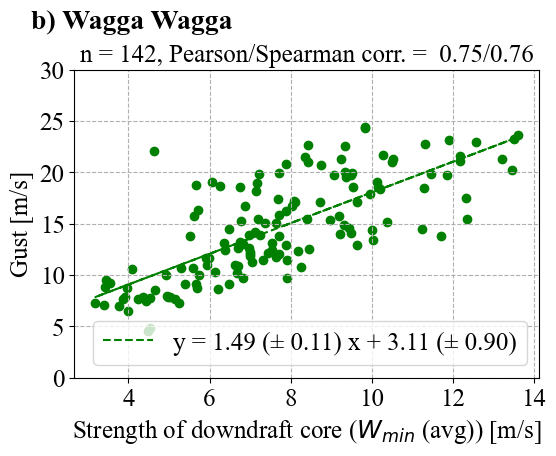

CASE3_new d03
Found 469 files


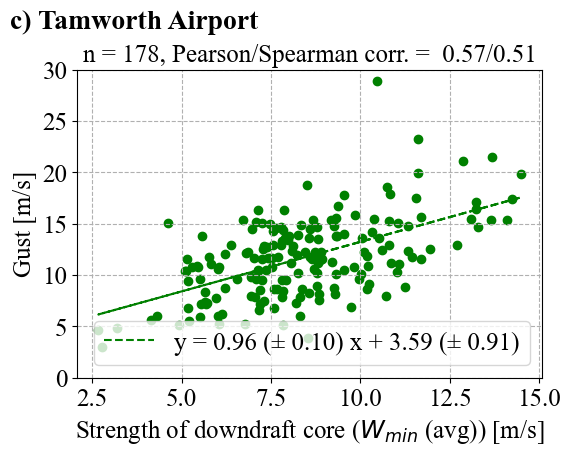

In [10]:
for case in cases:
    # Get data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)
    # Plot scatter
    index_plot = index_H2000
    
    fs = 18
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs,      # X tick label size
        "ytick.labelsize": fs,      # Y tick label size
        "legend.fontsize": fs,      # Legend font size
        "figure.titlesize": fs-2,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })
    
    plt.close("all")
    fig, ax = plt.subplots(figsize = (6,4))
    
    w_plots    = np.abs(np.array([np.mean(i) for i in w_min_all])[index_plot]) # Mean Wmin
    label_x = r"Strength of downdraft core ($W_{min}$ (avg)) [m/s]"
    ws10_plots = deepcopy(wspd10max_neigh)[index_plot]
    
    # Plot
    sc = ax.scatter(w_plots, ws10_plots, color = "green") #, cmap=cmap, norm=norm)
    ax.set_xlabel(label_x)
    ax.set_ylabel("Gust [m/s]")
    ax.set_ylim(0,30)
    
    # Correlations WITH statistical significance
    x, y = w_plots, ws10_plots
    corr_p1, p_value = scipy.stats.pearsonr(x, y)
    corr_p1 = corr_p1.round(2)
    corr_s1 = scipy.stats.spearmanr(x, y)[0].round(2)
    p, V = np.polyfit(x, y, 1, cov=True)
    slope, intercept = p
    slope_std     = np.round(np.sqrt(V[0][0]), 2)
    intercept_std = np.round(np.sqrt(V[1][1]), 2)
    regression_line = slope * x + intercept
    regression_line_label = f"y = {slope:.2f} (± {slope_std:.2f}) x + {intercept:.2f} (± {intercept_std:.2f})"
    ax.plot(x, regression_line, color='green', ls = "--", label=regression_line_label)
    ax.set_title(f"n = {len(x)}, Pearson/Spearman corr. =  {corr_p1}/{corr_s1}", loc = "center")
    
    ax.grid(ls = "--")
    ax.legend(loc = 4, frameon = True)
    plt.suptitle(f"{sub_case[case]}", fontweight = "bold", x = 0.22, y = 1.03, fontsize = fs + 2)
    plt.savefig(f"{path_figs}/Figure14_{case}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

## Figure S6: Histograms (sizes)

CASE1 d03
Found 1135 files


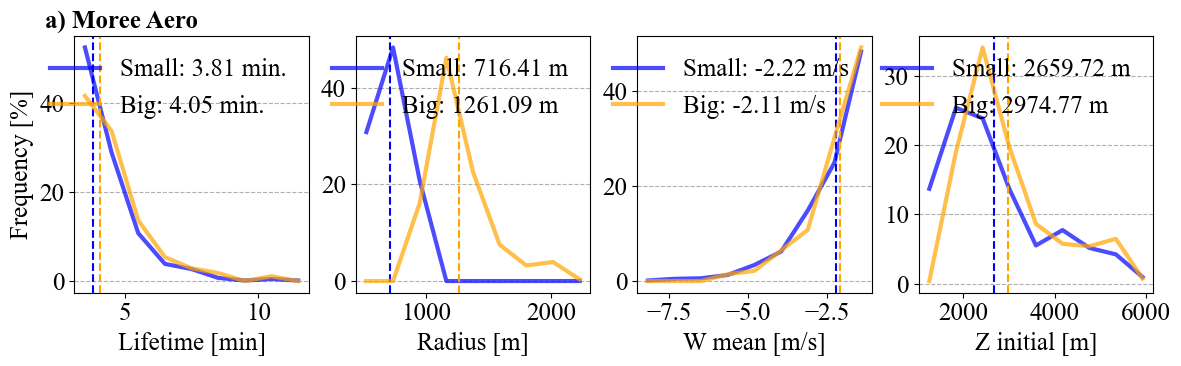

CASE2_new d03
Found 285 files


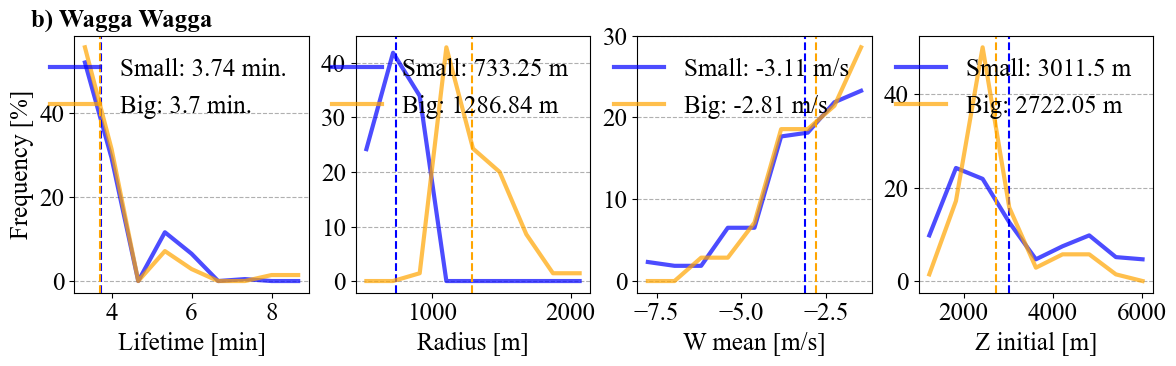

CASE3_new d03
Found 469 files


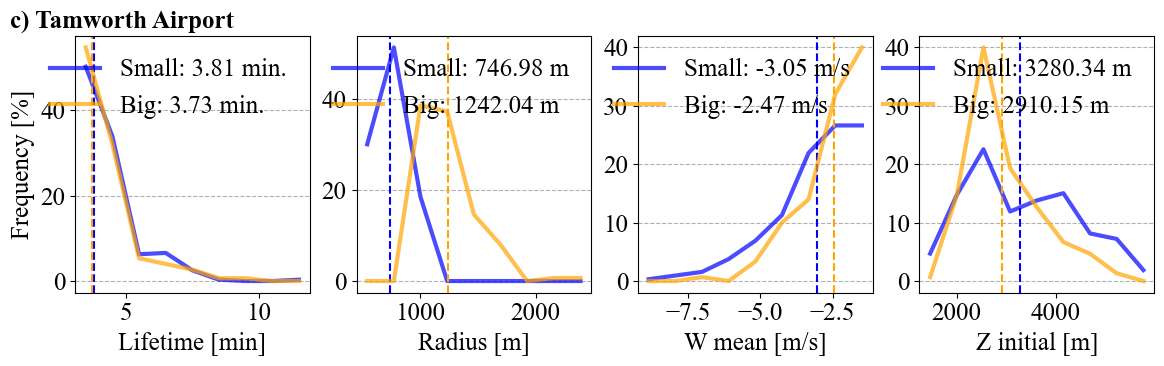

In [11]:
for case in cases:
    # Get data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)

    # Plot histograms
    plt.figure(figsize=(12,4))
    density_ = True
    nbins_ = 10
    labels_2 = ["Small", "Big"]
    
    #------------------------
    # Histograms of lifetime (min)
    #------------------------
    l1 = np.array([len(i) for i in time_all])
    l2 = l1[index_small] 
    l3 = l1[index_big]
    
    plt.subplot(1, 4, 1)
    plot_density_axis(plt.gca(), l2, l3, labels=labels_2, ylabel = True, x_label="Lifetime [min]", density=density_, nbins=nbins_,units = ["min.", "min."], legend = True)
    
    plt.title(f"{label_cases[case]} {name_cases[case]}", fontweight = "bold", x=0.2)
    
    #------------------------
    # Histograms of Radius: MEAN
    #------------------------
    r1 = r_mean
    r2 = r1[index_small] 
    r3 = r1[index_big]
    
    plt.subplot(1, 4, 2)
    plot_density_axis(plt.gca(), r2, r3, labels=labels_2, x_label="Radius [m]", density=density_, nbins=nbins_,units = ["m", "m"], legend = True)
    
    #------------------------------
    # Histograms of W: Mean from tracking code
    #------------------------------
    
    w1 = w_mean_mean
    w2 = w1[index_small]
    w3 = w1[index_big]
    
    plt.subplot(1, 4, 3)
    plot_density_axis(plt.gca(), w2, w3, labels=labels_2, x_label="W mean [m/s]", density=density_, nbins=nbins_, units = ["m/s", "m/s"], legend = True)
    
    #------------------------
    # Histograms of Initial Z
    #------------------------
    idx_t = 0
    z1 = z_init
    z2 = z1[index_small] 
    z3 = z1[index_big] 
    
    plt.subplot(1, 4, 4)
    plot_density_axis(plt.gca(), z2, z3, labels=labels_2, x_label="Z initial [m]", density=density_, nbins=nbins_, units = ["m", "m"], legend = True)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.20)
    plt.savefig(f"{path_figs}/FigureS6_{case}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

## Figure S7: Scatters (others W)

CASE1 d03
Found 1135 files


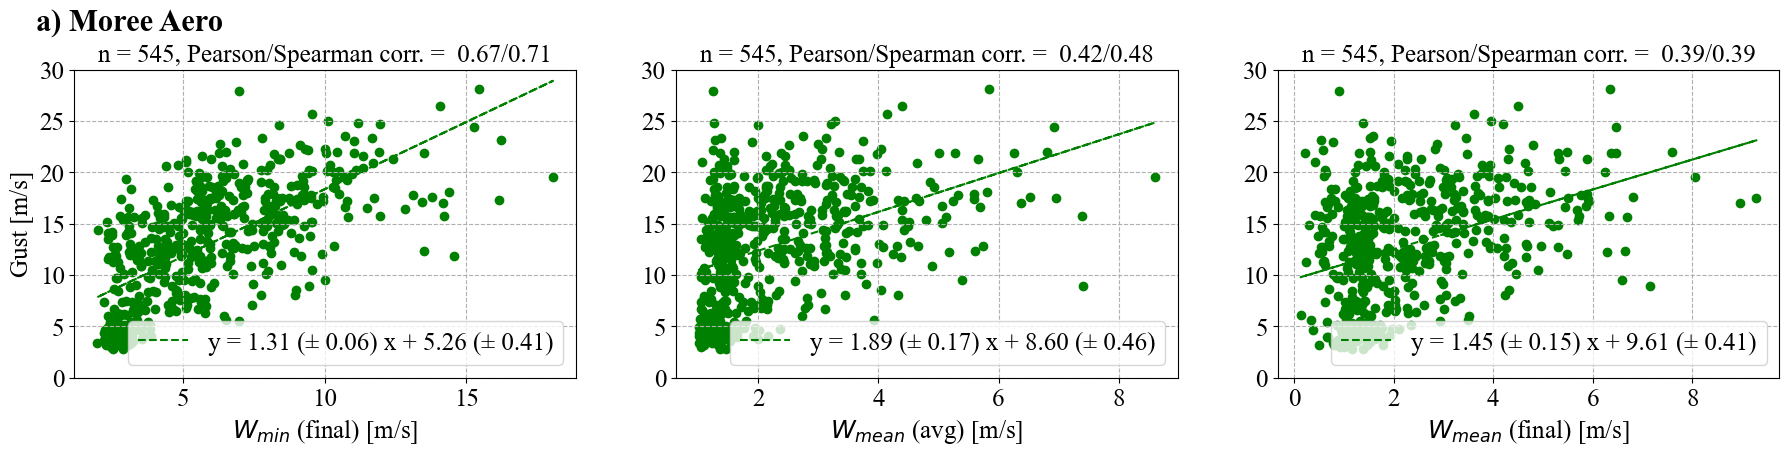

CASE2_new d03
Found 285 files


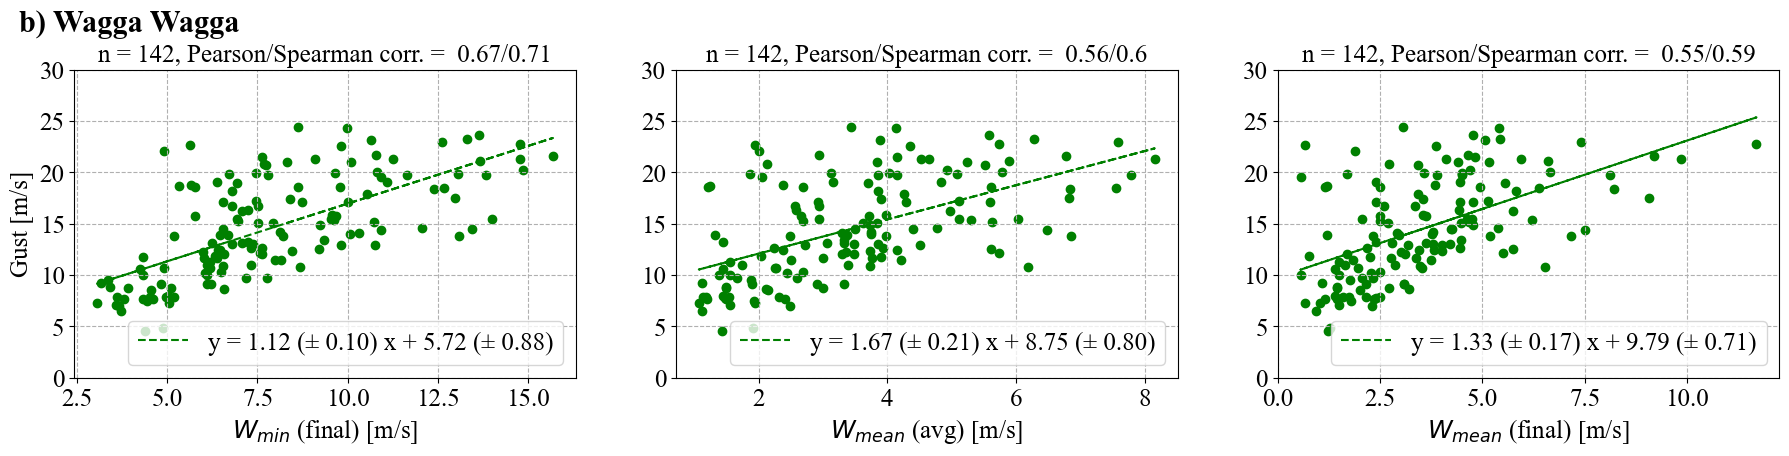

CASE3_new d03
Found 469 files


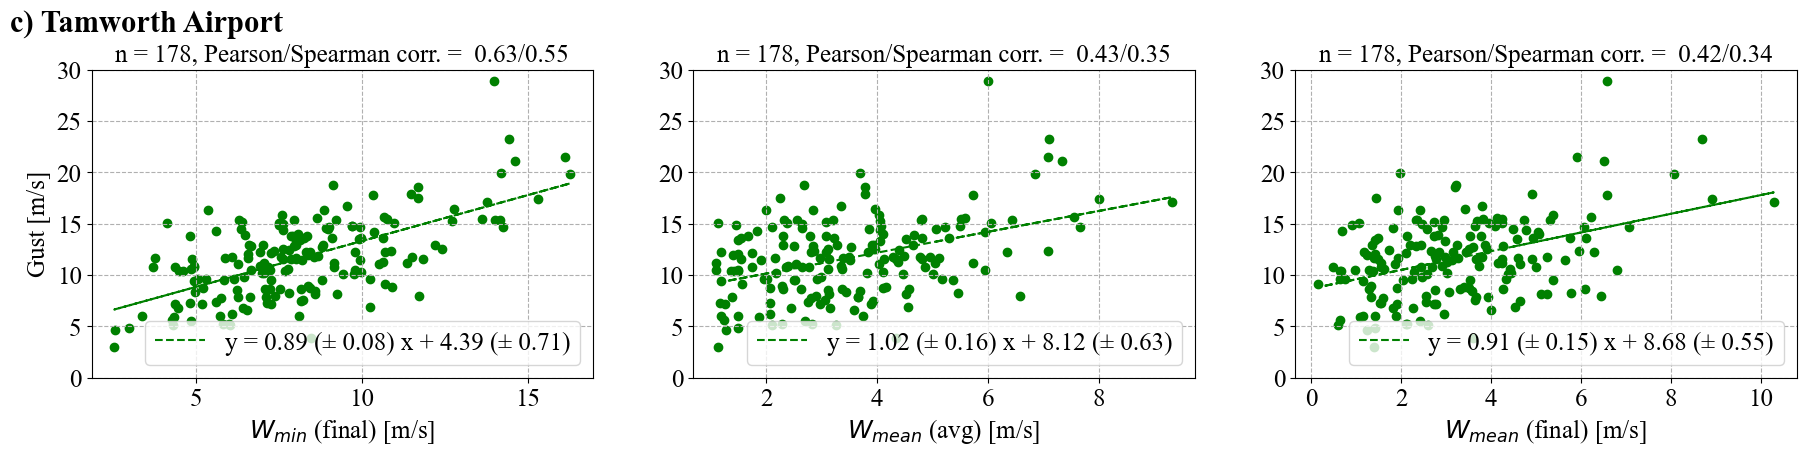

In [13]:
for case in cases:
    # Get data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)

    # Plot scatters
    fs = 18
    plt.rcParams.update({
        "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": fs,       # Title size for subplots
        "axes.labelsize": fs,       # Axis label size
        "xtick.labelsize": fs,      # X tick label size
        "ytick.labelsize": fs,      # Y tick label size
        "legend.fontsize": fs,      # Legend font size
        "figure.titlesize": fs-2,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })
    
    # Scatter plots
    index_plot = index_H2000
    
    w_plots1    = np.abs(np.array([i[-1] for i in w_min_all])[index_plot]) # Final Wmin
    w_plots2    = np.abs(np.array([np.mean(i) for i in w_mean_all])[index_plot]) # Mean W
    w_plots3    = np.abs(np.array([i[-1] for i in w_mean_all])[index_plot]) # Final Wmean
    ws10_plots = deepcopy(wspd10max_neigh)[index_plot]
    
    xlabel1 = r"$W_{min}$ (final) [m/s]"
    xlabel2 = r"$W_{mean}$ (avg) [m/s]"
    xlabel3 = r"$W_{mean}$ (final) [m/s]"
    
    plt.close("all")
    fig, axes = plt.subplots(figsize = (22,4), nrows = 1, ncols = 3)
    c = 0
    for w_plots, label_x, idx_ in zip ([w_plots1, w_plots2, w_plots3], [xlabel1, xlabel2, xlabel3], [1,2,3]):
    
        ax = axes.flatten()[c]
        # Plot
        sc = ax.scatter(w_plots, ws10_plots, color = "green") #, cmap=cmap, norm=norm)
        ax.set_xlabel(label_x)
        if idx_ == 1: ax.set_ylabel("Gust [m/s]")
        ax.set_ylim(0,30)
    
        # Correlations 
        x, y = w_plots, ws10_plots
        corr_p1 = scipy.stats.pearsonr(x, y)[0].round(2)
        corr_s1 = scipy.stats.spearmanr(x, y)[0].round(2)
        p, V = np.polyfit(x, y, 1, cov=True)
        slope, intercept = p
        slope_std     = np.round(np.sqrt(V[0][0]), 2)
        intercept_std = np.round(np.sqrt(V[1][1]), 2)
        regression_line = slope * x + intercept
        regression_line_label = f"y = {slope:.2f} (± {slope_std:.2f}) x + {intercept:.2f} (± {intercept_std:.2f})"
        ax.plot(x, regression_line, color='green', ls = "--", label=regression_line_label)
        ax.set_title(f"n = {len(x)}, Pearson/Spearman corr. =  {corr_p1}/{corr_s1}", loc = "center")
    
        ax.grid(ls = "--")
        ax.legend(loc = 4, frameon = True)
    
        c = c+ 1
    plt.suptitle(f"{sub_case[case]}", fontweight = "bold", x = 0.15, y = 1.03, fontsize = fs + 4)
    plt.savefig(f"{path_figs}/FigureS7_{case}.png", dpi = 300, bbox_inches = "tight")
    plt.show()


## Figure S8: Correlation (different buffers)

CASE1 d03
Found 1135 files


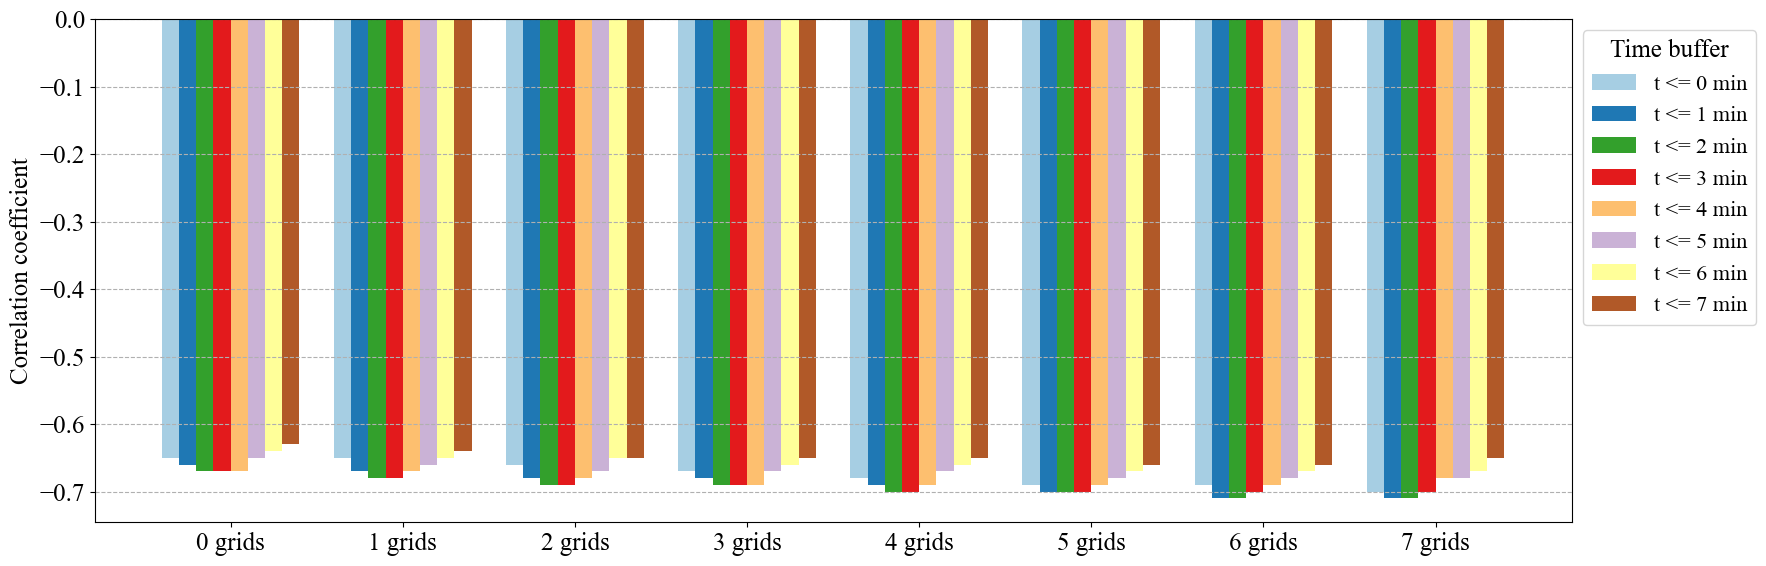

CASE2_new d03
Found 285 files


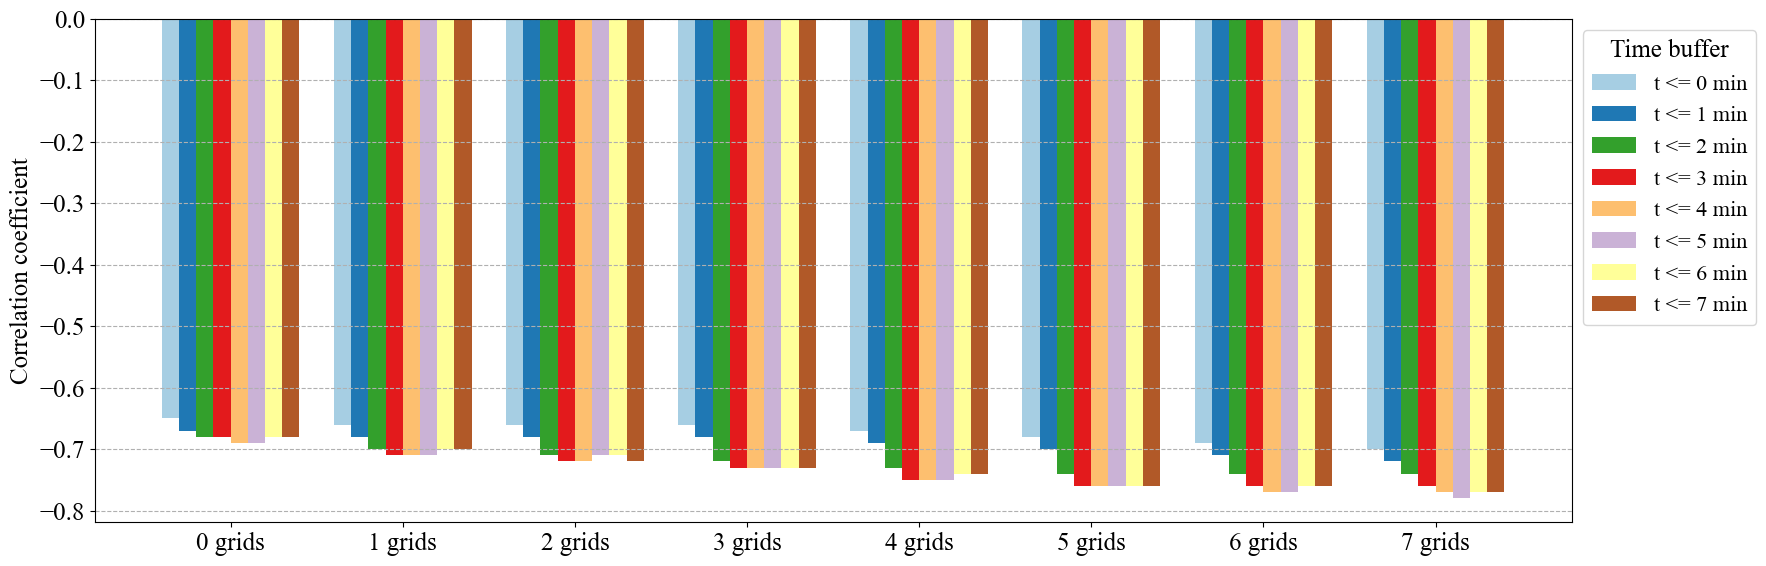

CASE3_new d03
Found 469 files


In [ ]:
for case in cases:
    # Get data
    index_all, ix_max_all, iy_max_all, iz_max_all, indx_all, indy_all, indz_all,  w_min_all,  w_mean_all, wspd10max_neigh, time_all, r_mean, w_mean_mean, z_init, z_final, z_max_all, t_max_all,  index_H2000, index_big, index_small, wrf_all = get_all_data(case)

    # Get correlation with different parameters, and plot 
    def get_corr_all(threshold_h = 2000, p1_aux = list(range(0,6)), p2_aux = list(range(0,6))):
    
        w_plots = np.array([np.mean(i) for i in w_min_all])
    
        fs = 18
        plt.rcParams.update({
            "font.size": fs,            # Controls most text: tick labels, axis labels, legend, etc.
            "axes.titlesize": fs,       # Title size for subplots
            "axes.labelsize": fs,       # Axis label size
            "xtick.labelsize": fs,      # X tick label size
            "ytick.labelsize": fs,      # Y tick label size
            "legend.fontsize": fs-2,      # Legend font size
            "figure.titlesize": fs,     # Figure-wide title size (if you use `fig.suptitle`),
             "font.family": "Times New Roman",
        })
                
        ### Scatter plots of final buffer
        def expand_array(arr, N):
            # Expand the array by N-1 numbers before the first element and after the last element
            if (arr[0] - N) >= 0:
                lim_ = arr[0] - N
            else:
                lim_ = 0
            return np.arange(lim_, arr[-1] + N + 1)
    
        #Get combinations of parameters p1: buffer in #grids, p2: buffer in time (min)
        p1_list_all = []
        p2_list_all = []
        for p1 in p1_aux:
            for p2 in p2_aux:
                p1_list_all.append(p1)
                p2_list_all.append(p2)
    
        # Get maximum horizontal wind speed at the end of the downdraft
        ws_max       = wrf_all["WSMAX"]
        compute_wmax = True
        correlations_all = {}
        
        # Define lists of parameters: 
        for p1, p2 in zip(p1_list_all, p2_list_all):
    
            wspd10max_end, wspd10max_neigh = [], []
            for thermal_idx in index_all:
                # Positions of wmax
                ix_max = ix_max_all[thermal_idx]
                iy_max = iy_max_all[thermal_idx]
    
                # I am just looking at the end of each dd lifetime
                times_thermal = t_max_all[thermal_idx]
                idx_t         = len(times_thermal)-1 
                #print (f"Looking at downdraft {thermal_idx} during idx_time {times_thermal[idx_t]}")
    
                # Ws10max at the exact position (centre of DD)
                xr_pos = ws_max.isel(Time = times_thermal[idx_t], south_north = iy_max[idx_t], west_east = ix_max[idx_t])
                wspd10max_end.append(np.array(xr_pos).item())
    
                # Ws10max in the neighborhood of the dd
                idx_all_dd = expand_array(indx_all[thermal_idx][idx_t], p1)
                idy_all_dd = expand_array(indy_all[thermal_idx][idx_t], p1)
                idz_all_dd = expand_array(indz_all[thermal_idx][idx_t], p1)
                idt_all_dd = slice(times_thermal[idx_t],times_thermal[idx_t]+p2+1)
    
                test_neigh = ws_max.isel(Time = idt_all_dd, 
                          south_north = idy_all_dd,
                          west_east   = idx_all_dd)
    
                wspd10max_neigh.append(np.array(test_neigh.max()))
    
            wspd10max_end   = np.array(wspd10max_end)
            wspd10max_neigh = np.array(wspd10max_neigh)
    
            ## Scatter plots
            z_plots    = deepcopy(z_final)
            ws10_plots = deepcopy(wspd10max_neigh)
    
            condition_height = z_plots<=threshold_h
            
            # Correlations height
            x1, y1 = w_plots[condition_height], ws10_plots[condition_height]
            corr_p1 = scipy.stats.pearsonr(x1, y1)[0].round(2)
            correlations_all[f"{p1}-{p2}"] = corr_p1
    
        # Step 1: Group the correlations_all dictionary by the first number (before the '-')
        grouped_correlations = {}
        for key, value in correlations_all.items():
            group, sub_group = key.split('-')
            group = int(group)
            sub_group = int(sub_group)
    
            if group not in grouped_correlations:
                grouped_correlations[group] = []
    
            grouped_correlations[group].append(value)
    
        x_labels = sorted(grouped_correlations.keys())
        bar_width = 0.10
        index = np.arange(len(x_labels))
    
        colors = plt.cm.Paired(np.linspace(0, 1, max(len(v) for v in grouped_correlations.values())))
    
        #-------------------------
        # PLOT CORR 
        #-------------------------
        
        fig, ax = plt.subplots(figsize=(18, 6))
    
        # Plot correlations on the first axis (ax)
        #ax = axes[1]
        for i, group in enumerate(x_labels):
            values = grouped_correlations[group]
    
            # Color for each subgroup
            for j, value in enumerate(values):
                ax.bar(index[i] + bar_width * j, value, bar_width, label=f't <= {p2_aux[j]} min' if i == 0 else "", color=colors[j])
    
        # Add labels, title, and legend for correlations
        ax.set_ylabel(r'Correlation coefficient')
        ax.set_xticks(index + bar_width * (len(values) - 1) / 2)
        ax.set_xticklabels([f'{x} grids' for x in x_labels])
    
        # Remove duplicate legends for the first plot
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = []
        unique_handles = []
        for handle, label in zip(handles, labels):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_handles.append(handle)
    
        ax.legend(unique_handles, unique_labels, title='Time buffer', bbox_to_anchor=(1., 1.))
        ax.grid(ls="--", axis="y")
    
        plt.tight_layout()
        plt.savefig(f"{path_figs}/FigureS8_{case}.png", dpi = 300, bbox_inches = "tight")
        plt.show()
    
    get_corr_all(p1_aux = list(range(0,8)), p2_aux = list(range(0,8)))
